In [99]:
import pandas as pd
from matplotlib import pyplot as plt

file_path = '../results/summary.csv'

df = pd.read_csv(
    file_path,
    sep=",",
    index_col="config_id"
)

df.columns = df.columns.str.strip()

df.head()

,n,f,tle_ms,alpha,avg_first_latency_us,avg_decisions,agreement_ok
config_id,,,,,,,
1,3,1,1000,0.0,955,3.0,True
2,3,1,200,0.0,680,3.0,True
3,3,1,100,0.0,390,3.0,True
4,3,1,10,0.0,455,3.0,True
5,3,1,1,0.0,547,3.0,True


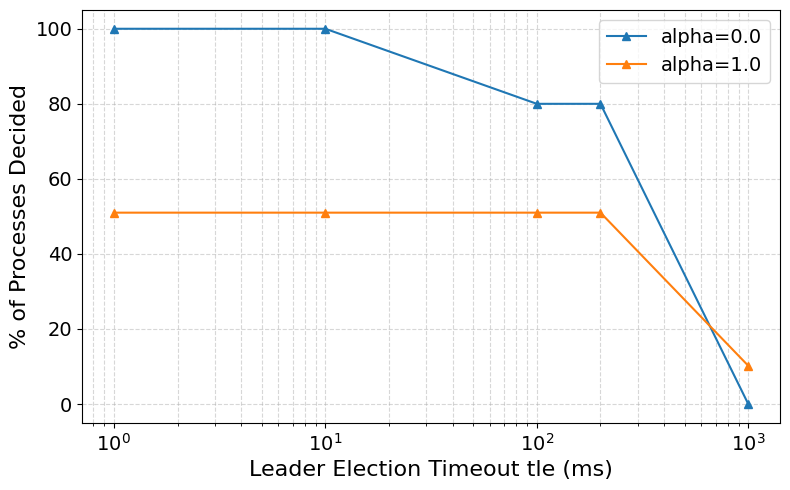

In [ ]:
def plot_decisions_vs_tle(df, n_val):
    fig, ax = plt.subplots(figsize=(8,5))
    df_n = df[df["n"] == n_val]
    
    for alpha_val in sorted(df_n['alpha'].unique()):
        if alpha_val == 0.1:
            continue
        subset = df_n[df_n['alpha'] == alpha_val].sort_values('tle_ms')
        ax.plot(subset['tle_ms'], subset['avg_decisions'] / n_val * 100, marker='^', label=f'alpha={alpha_val}')
    
    ax.set_xlabel('Leader Election Timeout tle (ms)', fontsize=16)
    ax.set_ylabel('% of Processes Decided', fontsize=16)
    ax.tick_params(labelsize=14, color='black')
    
    ax.set_xscale('log')
    ax.set_ylim(-5, 105) 
    
    ax.legend(fontsize=14)
    ax.grid(True, which="both", ls="--", alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(f'img/decisions_vs_tle_n_{n_val}.pdf', bbox_inches='tight')
    plt.show()

plot_decisions_vs_tle(df, 100)

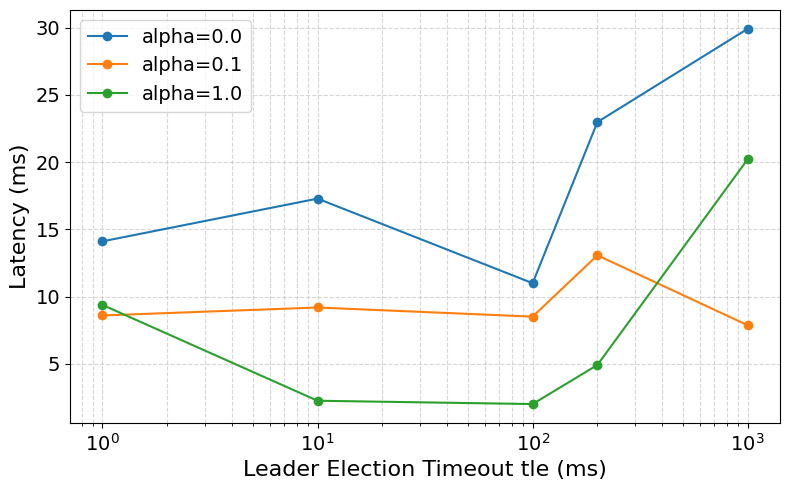

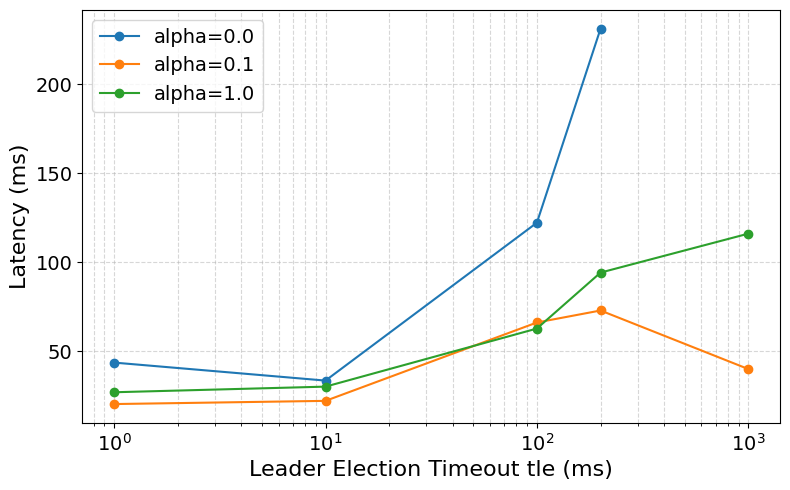

In [ ]:
def plot_latency_vs_tle(df, n_val):
    fig, ax = plt.subplots(figsize=(8,5))
    
    # filter for a specific n and remove the -1 timeouts
    df_n = df[(df["n"] == n_val) & (df["avg_first_latency_us"] > 0)]
    
    for alpha_val in sorted(df_n['alpha'].unique()):
        subset = df_n[df_n['alpha'] == alpha_val].sort_values('tle_ms')
        ax.plot(subset['tle_ms'], subset['avg_first_latency_us']/1000, marker='o', label=f'alpha={alpha_val}')
    
    ax.set_xlabel('Leader Election Timeout tle (ms)', fontsize=16)
    ax.set_ylabel('Latency (ms)', fontsize=16)
    ax.tick_params(labelsize=14, color='black')
    
    ax.set_xscale('log')
    # ax.set_yscale('log')
    
    ax.legend(fontsize=14)
    ax.grid(True, which="both", ls="--", alpha=0.5)
    # ax.set_title(f'latency vs timeout (N={n_val})', fontsize=18)
    
    plt.tight_layout()
    plt.savefig(f'img/lat_vs_tle_n_{n_val}.pdf', bbox_inches='tight')
    plt.show()

plot_latency_vs_tle(df, 30)
plot_latency_vs_tle(df, 70)

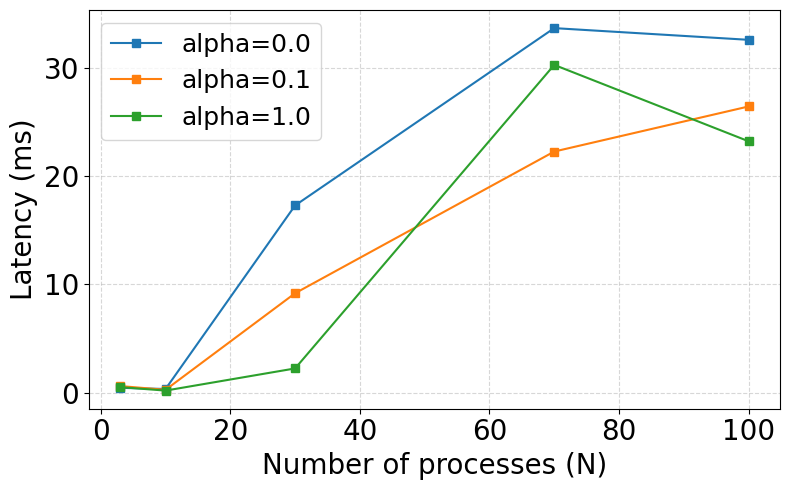

In [105]:
#does this make sense?
def plot_latency_vs_n(df, tle):
    fig, ax = plt.subplots(figsize=(8,5))
    df = df[df["tle_ms"] == tle]

    for m_val in sorted(df['alpha'].unique()):
        subset = df[df['alpha'] == m_val].sort_values('n')
        ax.plot(subset['n'], subset['avg_first_latency_us']/1000, marker='s', label=f'alpha={m_val}')

    ax.set_xlabel('Number of processes (N)', fontsize=20)
    ax.set_ylabel('Latency (ms)', fontsize=20)
    ax.tick_params(labelsize=20, color='black')

    # ax.set_xscale('log')
    # ax.set_yscale('log')

    ax.legend(fontsize=18)
    ax.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(f'img/lat_vs_n_tle_{tle}.pdf', bbox_inches='tight')
    plt.show()

tle = 10
plot_latency_vs_n(df, tle)